# Intra vs extra donut blur across the Danish 1.3 blitz FAM ensemble (v1)

**Author:** Aaron Roodman  
**Date Created:** 2026-10-03  
**Last Modified:** 2026-10-03  
**Status:** In Progress  
**Keywords:** FAM, donut blur, Danish 1.3, blitz, unpaired, intra-focal, extra-focal, seeing, thermal telemetry  

## Description

Median donut blur per side of focus against FAM ordinal number, for the whole Danish 1.3
blitz unpaired FAM ensemble, and a test of what kind of offset separates the two sides.

Key functionality:
1. Read the per-side blur medians `median_blur_intra_arcsec` and
   `median_blur_extra_arcsec` from the blitz recast `visits.parquet`.
2. Plot both sides against FAM ordinal number, with a different marker and colour per
   side.
3. Fit three one-parameter models of the intra/extra relation — constant, fractional and
   quadrature — and compare them on robust residual scatter.
4. Test whether what remains tracks thermal telemetry: the air temperature differences
   between the truss, M2, M1M3, camera and outside air, and the M1M3 bulk thermal
   gradients. Correlations are reported both full-sample and within night, since the
   difference is largely a night-level quantity.

The ensemble matters because seeing drifts between the intra-focal and extra-focal
exposures of a single FAM triplet. One triplet cannot separate a real side-of-focus bias
from that drift; 966 triplets can, because the drift averages out while a systematic
offset does not.

**Output:** plots under `output/fam_processing/blur_intra_extra/`, plus a cached
`thermal_join.parquet` of the per-triplet thermal telemetry in the same directory.

**Based on:** `aos/docs/studies/fam_processing.md`, the `blitz_reader` recast of the
Danish 1.3 unpaired FAM product into the Danish 1.2 schema. The per-side columns this
notebook reads were added to `blitz_reader.donut_table` and `blitz_reader.visit_metrics`
on 2026-10-03; before that the recast kept only the two-side mean.


## Change Log

| Date | Author | Description |
|------|--------|-------------|
| 2026-10-03 | Aaron Roodman | Initial version |
| 2026-10-03 | Aaron Roodman | `day_obs` annotations and per-night medians on the ordinal plot; thermal telemetry section |


## Table of Contents

1. [Parameters](#params)
2. [Setup & Imports](#setup)
3. [Helper Functions](#functions)
4. [Data Access](#data)
5. [Blur vs FAM ordinal](#ordinal)
6. [What kind of offset?](#offset)
7. [Thermal dependence](#thermal)
8. [Summary](#summary)


<a id='params'></a>
## Parameters


In [1]:
# ============================================================
# Parameters
# ============================================================

PARAM_SET = 'danish_1_3_test'   # blitz recast of the Danish 1.3 unpaired FAM product
QUALITY_ONLY = True             # keep only visits with visit_quality_pass True
SAVE_PLOTS = True               # write PDFs under output/fam_processing/blur_intra_extra/

# Marker and colour per side of focus, used in every plot below.
SIDE_STYLE = {
    'intra': {'color': '#1f77b4', 'marker': 'o', 'label': 'intra-focal'},
    'extra': {'color': '#d62728', 'marker': '^', 'label': 'extra-focal'},
}


<a id='setup'></a>
## Setup & Imports


In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

_TOPIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'code').is_dir())
sys.path.insert(0, str(_TOPIC.parent))        # repo root -> common/
sys.path.insert(0, str(_TOPIC / 'code'))      # flat cross-study modules
for _d in sorted((_TOPIC / 'code').glob('*/')):
    if _d.is_dir() and not _d.name.startswith(('_', '.')):
        sys.path.insert(0, str(_d))

from common.utils import nmad, setup_plotting

setup_plotting()

OUT_DIR = _TOPIC / 'output' / 'fam_processing' / 'blur_intra_extra'
if SAVE_PLOTS:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'topic: {_TOPIC}')
print(f'output: {OUT_DIR}')


topic: /sdf/home/r/roodman/notebooks/rubin-work/aos
output: /sdf/home/r/roodman/notebooks/rubin-work/aos/output/fam_processing/blur_intra_extra


<a id='functions'></a>
## Helper Functions


In [3]:
def fit_offset_models(b_intra, b_extra):
    """Fit the three one-parameter models of the intra/extra blur relation.

    Each model has a single free parameter, so their residual scatters are directly
    comparable. Every parameter is estimated with a median rather than a mean, so a
    handful of bad visits cannot drive the comparison.

    Parameters
    ----------
    b_intra, b_extra : `numpy.ndarray`
        Per-visit median donut blur on each side of focus, in arcsec. Same length;
        non-finite entries are dropped pairwise.

    Returns
    -------
    models : `dict`
        One entry per model name (``'constant'``, ``'fractional'``, ``'quadrature'``),
        each a `dict` with ``param`` (the fitted parameter, units in ``param_units``),
        ``param_units``, ``predicted`` (predicted intra blur, arcsec), ``residual``
        (observed minus predicted intra blur, arcsec), ``nmad_arcsec`` (robust residual
        scatter, arcsec) and ``median_abs_arcsec`` (median absolute residual, arcsec).
        The extra key ``n`` is the number of triplets fitted, dimensionless.

    Notes
    -----
    The quadrature parameter is the median of ``b_intra**2 - b_extra**2`` in arcsec**2,
    which is signed: it is negative for an ensemble where intra is the sharper side. The
    predicted blur uses ``sqrt(max(b_extra**2 + q, 0))``.
    """
    b_intra = np.asarray(b_intra, dtype=float)
    b_extra = np.asarray(b_extra, dtype=float)
    ok = np.isfinite(b_intra) & np.isfinite(b_extra)
    bi, be = b_intra[ok], b_extra[ok]

    c = float(np.median(bi - be))
    f = float(np.median(bi / be))
    q = float(np.median(bi**2 - be**2))

    models = {
        'constant': {'param': c, 'param_units': 'arcsec',
                     'predicted': be + c},
        'fractional': {'param': f, 'param_units': 'dimensionless (intra/extra)',
                       'predicted': f * be},
        'quadrature': {'param': q, 'param_units': 'arcsec**2',
                       'predicted': np.sqrt(np.clip(be**2 + q, 0.0, None))},
    }
    for m in models.values():
        m['residual'] = bi - m['predicted']
        m['nmad_arcsec'] = float(nmad(m['residual']))
        m['median_abs_arcsec'] = float(np.median(np.abs(m['residual'])))
    models['n'] = int(ok.sum())
    return models


<a id='data'></a>
## Data Access

`visits.parquet` from the blitz recast carries one row per FAM triplet. The per-side
columns `median_blur_intra_arcsec` and `median_blur_extra_arcsec` are the median over
that side's donuts of the blitz `group_fwhm`, in arcsec; `median_blur_arcsec` is the
median of the two-side mean and is the column the quality cut uses.

The **FAM ordinal number** is the position of the triplet in time order across the whole
ensemble, so it indexes the triplet rather than the exposure.


In [4]:
visits_file = _TOPIC / 'output' / 'fam_processing' / PARAM_SET / 'visits.parquet'
v = pd.read_parquet(visits_file)

needed = ['median_blur_intra_arcsec', 'median_blur_extra_arcsec']
missing = [c for c in needed if c not in v.columns]
if missing:
    raise KeyError(
        f'{visits_file} lacks {missing}; rebuild it with '
        f'`python code/fam_processing/run_blitz_mktable.py --param-set {PARAM_SET} '
        f'--overwrite`, which writes the per-side blur medians')

v = v.sort_values(['day_obs', 'seq_num']).reset_index(drop=True)
print(f'{len(v)} FAM triplets, nights {v["day_obs"].min()} to {v["day_obs"].max()}, '
      f'{v["day_obs"].nunique()} nights')

if QUALITY_ONLY and 'visit_quality_pass' in v.columns:
    n_before = len(v)
    v = v[v['visit_quality_pass'].astype(bool)].reset_index(drop=True)
    print(f'quality cut (visit_quality_pass): kept {len(v)} of {n_before} triplets')

v['fam_ordinal'] = np.arange(1, len(v) + 1)

b_intra = v['median_blur_intra_arcsec'].to_numpy(float)
b_extra = v['median_blur_extra_arcsec'].to_numpy(float)
finite = np.isfinite(b_intra) & np.isfinite(b_extra)
print(f'both sides finite: {int(finite.sum())} of {len(v)} triplets')
print(f'median intra-focal blur = {np.nanmedian(b_intra):.4f} arcsec')
print(f'median extra-focal blur = {np.nanmedian(b_extra):.4f} arcsec')


966 FAM triplets, nights 20260315 to 20260619, 15 nights
quality cut (visit_quality_pass): kept 873 of 966 triplets
both sides finite: 873 of 873 triplets
median intra-focal blur = 1.0526 arcsec
median extra-focal blur = 0.6636 arcsec


<a id='ordinal'></a>
## Blur vs FAM ordinal

Both sides on one axis, intra-focal in blue circles and extra-focal in red triangles.
Grey vertical lines separate the nights and each block carries its `day_obs`, because the
difference between the two sides is far more a night-level quantity than a within-night
one: the lower panel's per-night medians run from roughly 0.1 to 0.5 arcsec while the
scatter inside a night is smaller than that spread.

That night-to-night structure is what motivates the thermal section below.


/lscratch/roodman/ipykernel_3523135/4200600601.py:55: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


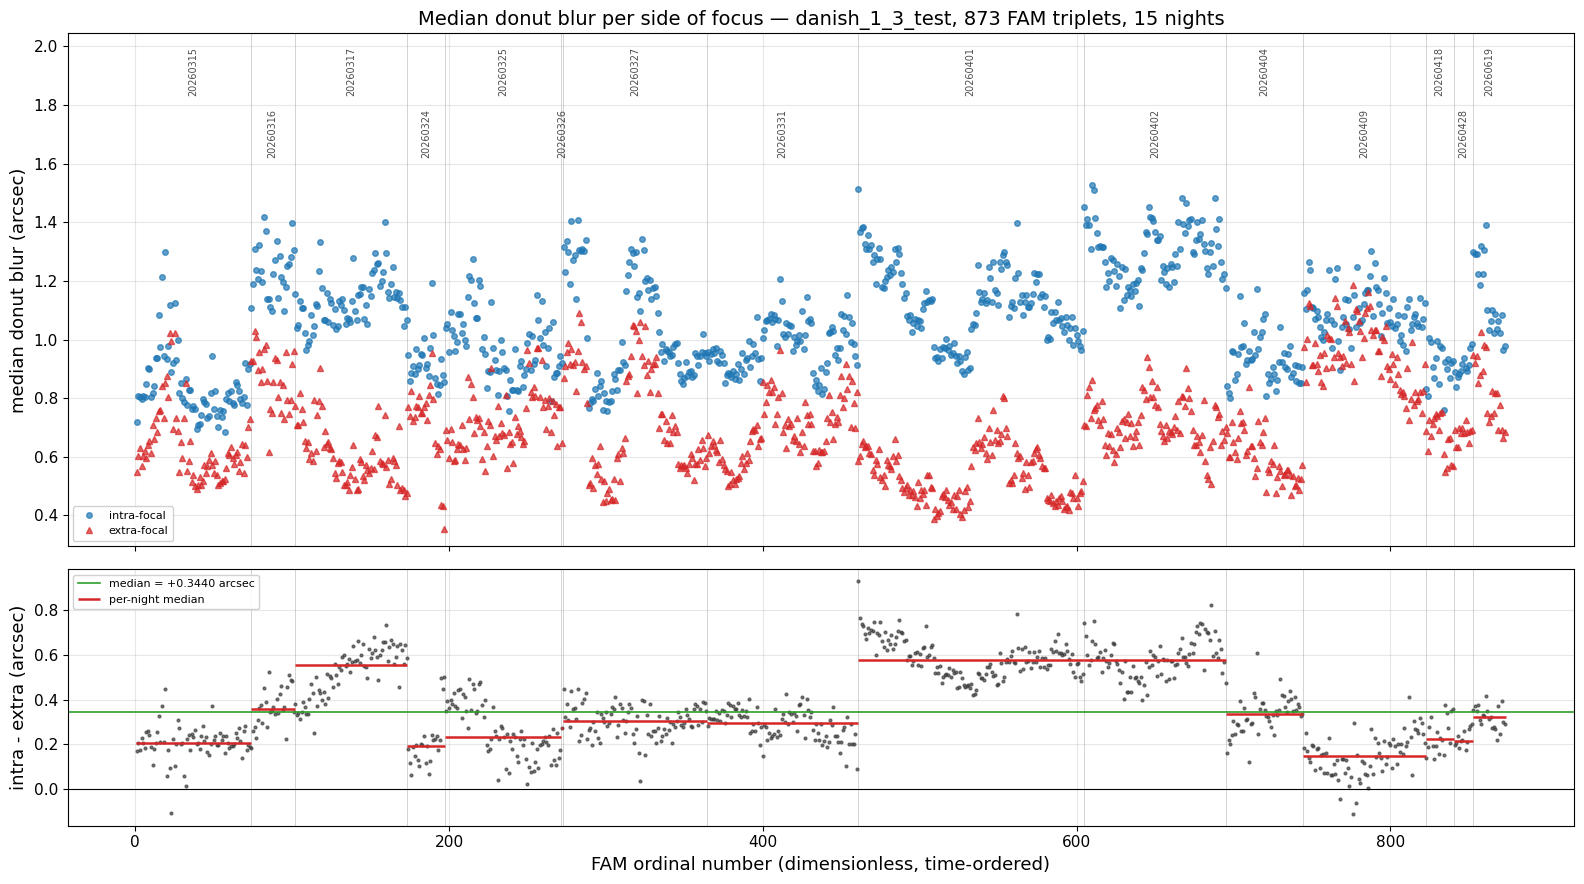

In [5]:
fig, axs = plt.subplots(2, 1, figsize=(16, 9), sharex=True,
                        gridspec_kw={'height_ratios': [2, 1]})

ax = axs[0]
for key, values in (('intra', b_intra), ('extra', b_extra)):
    s = SIDE_STYLE[key]
    ax.plot(v['fam_ordinal'], values, linestyle='none', marker=s['marker'],
            color=s['color'], markersize=4, alpha=0.7, label=s['label'])

# Night boundaries, plus the day_obs of each night written above its block of triplets.
# Which night a block belongs to is the whole point of the figure: the intra/extra
# difference changes from night to night by much more than it varies within one night.
day_obs_arr = v['day_obs'].to_numpy()
night_edges = np.flatnonzero(np.diff(day_obs_arr) != 0) + 1
block_starts = np.concatenate(([0], night_edges))
block_ends = np.concatenate((night_edges, [len(v)]))

ymax = float(np.nanmax([np.nanmax(b_intra), np.nanmax(b_extra)]))
ax.set_ylim(top=ymax * 1.34)
# Alternating heights so a short night's label does not collide with its neighbour, and
# the labels sit above the legend rather than behind it.
for j, (i0, i1) in enumerate(zip(block_starts, block_ends)):
    ax.text(0.5 * (i0 + i1) + 0.5, ymax * (1.31 if j % 2 == 0 else 1.17),
            str(int(day_obs_arr[i0])), rotation=90, ha='center', va='top',
            fontsize=7, color='0.3')

for ax_ in axs:
    for e in night_edges:
        ax_.axvline(e + 0.5, color='0.8', linewidth=0.6, zorder=0)

ax.set_ylabel('median donut blur (arcsec)')
ax.set_title(f'Median donut blur per side of focus — {PARAM_SET}, '
             f'{len(v)} FAM triplets, {v["day_obs"].nunique()} nights')
ax.legend(loc='lower left', framealpha=0.9, fontsize=8)

ax = axs[1]
diff = b_intra - b_extra
ax.plot(v['fam_ordinal'], diff, linestyle='none', marker='.', color='0.25',
        markersize=4, alpha=0.7)
ax.axhline(0.0, color='k', linewidth=0.8)
ax.axhline(float(np.nanmedian(diff)), color='#2ca02c', linewidth=1.2,
           label=f'median = {np.nanmedian(diff):+.4f} arcsec')

# Per-night median of the difference, to show it is a night-level quantity.
for i0, i1 in zip(block_starts, block_ends):
    med_night = float(np.nanmedian(diff[i0:i1]))
    ax.plot([i0 + 0.5, i1 + 0.5], [med_night, med_night], color='#d62728',
            linewidth=1.8, solid_capstyle='butt',
            label='per-night median' if i0 == 0 else None)

ax.set_xlabel('FAM ordinal number (dimensionless, time-ordered)')
ax.set_ylabel('intra - extra (arcsec)')
ax.legend(loc='upper left', framealpha=0.9, fontsize=8)

fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(OUT_DIR / 'blur_vs_fam_ordinal.pdf')
plt.show()


<a id='offset'></a>
## What kind of offset?

Three one-parameter models, each fitted by a median so outlying triplets cannot drive the
comparison:

| model | relation | parameter |
|---|---|---|
| constant | `b_intra = b_extra + c` | `c` in arcsec |
| fractional | `b_intra = f * b_extra` | `f` dimensionless |
| quadrature | `b_intra**2 = b_extra**2 + q` | `q` in arcsec**2 |

The discriminator is how the intra/extra difference trends with the blur itself. A
constant offset means the difference is flat against extra blur; a fractional offset
means it grows linearly; a quadrature offset means it *falls* as blur grows, because
adding in quadrature matters less when the base is already large.


In [6]:
models = fit_offset_models(b_intra, b_extra)
n_fit = models['n']

print(f'n = {n_fit} FAM triplets with both sides finite\n')
summary = pd.DataFrame([
    {'model': name,
     'parameter': f"{models[name]['param']:+.5f}",
     'units': models[name]['param_units'],
     'resid nMAD (arcsec)': f"{models[name]['nmad_arcsec']:.5f}",
     'median |resid| (arcsec)': f"{models[name]['median_abs_arcsec']:.5f}"}
    for name in ('constant', 'fractional', 'quadrature')])
print(summary.to_string(index=False))

best = min(('constant', 'fractional', 'quadrature'),
           key=lambda k: models[k]['nmad_arcsec'])
print(f'\nlowest robust residual scatter: {best}')


n = 873 FAM triplets with both sides finite

     model parameter                       units resid nMAD (arcsec) median |resid| (arcsec)
  constant  +0.34395                      arcsec             0.20379                 0.13745
fractional  +1.49989 dimensionless (intra/extra)             0.23984                 0.16177
quadrature  +0.56140                   arcsec**2             0.17863                 0.12049

lowest robust residual scatter: quadrature


/lscratch/roodman/ipykernel_3523135/2163611049.py:67: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


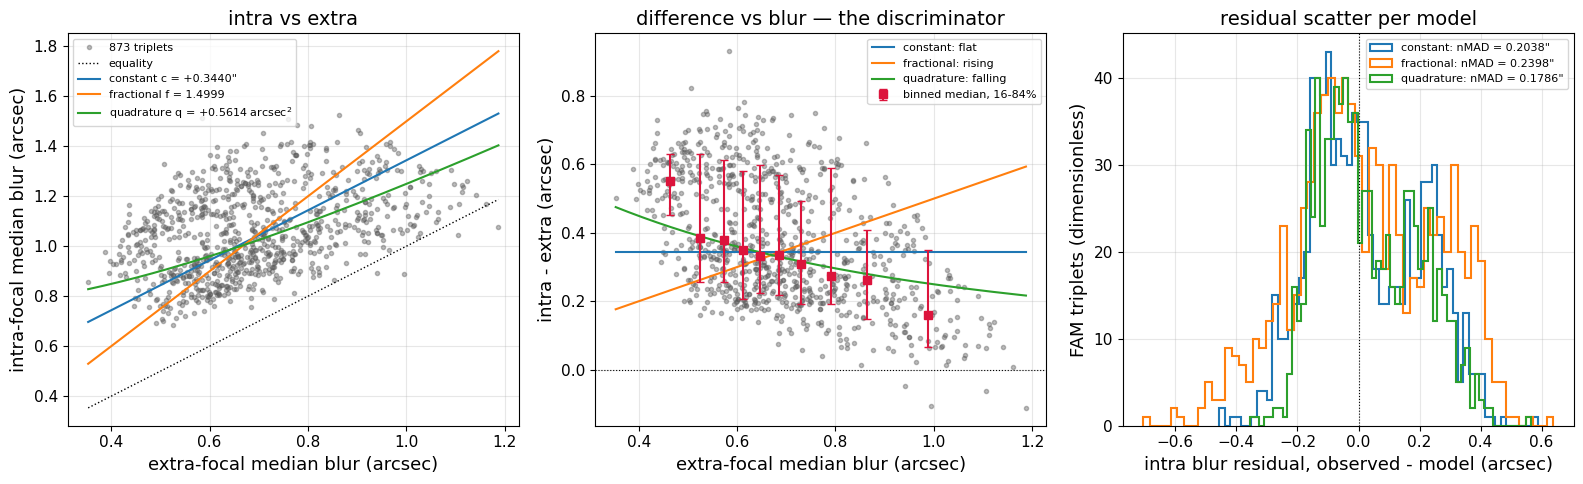

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

ok = np.isfinite(b_intra) & np.isfinite(b_extra)
bi, be = b_intra[ok], b_extra[ok]
grid = np.linspace(np.min(be), np.max(be), 200)

# Panel 1: intra against extra, with the three fitted relations.
ax = axs[0]
ax.plot(be, bi, linestyle='none', marker='o', markersize=3, alpha=0.4,
        color='0.35', label=f'{n_fit} triplets')
ax.plot(grid, grid, color='k', linewidth=1.0, linestyle=':', label='equality')
ax.plot(grid, grid + models['constant']['param'], color='#1f77b4', linewidth=1.5,
        label=f"constant c = {models['constant']['param']:+.4f}\"")
ax.plot(grid, models['fractional']['param'] * grid, color='#ff7f0e', linewidth=1.5,
        label=f"fractional f = {models['fractional']['param']:.4f}")
ax.plot(grid, np.sqrt(np.clip(grid**2 + models['quadrature']['param'], 0, None)),
        color='#2ca02c', linewidth=1.5,
        label=f"quadrature q = {models['quadrature']['param']:+.4f} arcsec$^2$")
ax.set_xlabel('extra-focal median blur (arcsec)')
ax.set_ylabel('intra-focal median blur (arcsec)')
ax.set_title('intra vs extra')
ax.legend(fontsize=8, loc='upper left')

# Panel 2: the discriminator — difference against extra blur.
ax = axs[1]
ax.plot(be, bi - be, linestyle='none', marker='o', markersize=3, alpha=0.4, color='0.35')
ax.axhline(0.0, color='k', linewidth=0.8, linestyle=':')
ax.plot(grid, np.full_like(grid, models['constant']['param']), color='#1f77b4',
        linewidth=1.5, label='constant: flat')
ax.plot(grid, (models['fractional']['param'] - 1.0) * grid, color='#ff7f0e',
        linewidth=1.5, label='fractional: rising')
ax.plot(grid, np.sqrt(np.clip(grid**2 + models['quadrature']['param'], 0, None)) - grid,
        color='#2ca02c', linewidth=1.5, label='quadrature: falling')

# Binned medians of the observed difference: the data's own answer, model-free.
edges = np.quantile(be, np.linspace(0, 1, 11))
centers, med, lo, hi = [], [], [], []
for a, b in zip(edges[:-1], edges[1:]):
    sel = (be >= a) & (be <= b) if b == edges[-1] else (be >= a) & (be < b)
    if sel.sum() >= 5:
        d = (bi - be)[sel]
        centers.append(float(np.median(be[sel])))
        med.append(float(np.median(d)))
        lo.append(float(np.percentile(d, 16)))
        hi.append(float(np.percentile(d, 84)))
med, lo, hi = np.array(med), np.array(lo), np.array(hi)
ax.errorbar(centers, med, yerr=[med - lo, hi - med], fmt='s', color='crimson',
            markersize=6, capsize=3, linewidth=1.5, label='binned median, 16-84%')
ax.set_xlabel('extra-focal median blur (arcsec)')
ax.set_ylabel('intra - extra (arcsec)')
ax.set_title('difference vs blur — the discriminator')
ax.legend(fontsize=8)

# Panel 3: residual distributions, one histogram per model.
ax = axs[2]
for name, color in (('constant', '#1f77b4'), ('fractional', '#ff7f0e'),
                    ('quadrature', '#2ca02c')):
    m = models[name]
    ax.hist(m['residual'], bins=60, histtype='step', linewidth=1.5, color=color,
            label=f"{name}: nMAD = {m['nmad_arcsec']:.4f}\"")
ax.axvline(0.0, color='k', linewidth=0.8, linestyle=':')
ax.set_xlabel('intra blur residual, observed - model (arcsec)')
ax.set_ylabel('FAM triplets (dimensionless)')
ax.set_title('residual scatter per model')
ax.legend(fontsize=8)

fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(OUT_DIR / 'blur_offset_models.pdf')
plt.show()


### Trend of the difference, quantified

The binned medians above are the direct test. Fitting a line to `intra - extra` against
extra blur separates the three models by its slope alone:

- slope ~ 0 with a non-zero intercept: **constant** offset
- slope ~ `f - 1` > 0 through the origin: **fractional** offset
- slope < 0: **quadrature** offset

Huber robust linear regression, the repository default for a calibration line of this
kind.


In [8]:
X = sm.add_constant(be)
rlm = sm.RLM(bi - be, X, M=sm.robust.norms.HuberT()).fit()
intercept, slope = float(rlm.params[0]), float(rlm.params[1])
intercept_err, slope_err = float(rlm.bse[0]), float(rlm.bse[1])

print(f'Huber RLM of (intra - extra) in arcsec on extra blur in arcsec, '
      f'n = {n_fit} triplets')
print(f'  intercept = {intercept:+.5f} +/- {intercept_err:.5f} arcsec')
print(f'  slope     = {slope:+.5f} +/- {slope_err:.5f} arcsec per arcsec '
      f'(dimensionless)')
print(f'  a fractional offset would predict slope = '
      f'{models["fractional"]["param"] - 1.0:+.5f} (dimensionless)')
print(f'  a constant offset would predict slope = +0.00000 (dimensionless)')

r, p_r = stats.pearsonr(be, bi - be)
rho, p_rho = stats.spearmanr(be, bi - be)
print(f'\n(intra - extra) in arcsec vs extra blur in arcsec, n = {n_fit} triplets:')
print(f'  Pearson r    = {r:+.4f} (p = {p_r:.3e})')
print(f'  Spearman rho = {rho:+.4f} (p = {p_rho:.3e})')

r2, p_r2 = stats.pearsonr(be, bi)
rho2, p_rho2 = stats.spearmanr(be, bi)
print(f'\nintra blur vs extra blur, both arcsec, n = {n_fit} triplets:')
print(f'  Pearson r    = {r2:+.4f} (p = {p_r2:.3e})')
print(f'  Spearman rho = {rho2:+.4f} (p = {p_rho2:.3e})')


Huber RLM of (intra - extra) in arcsec on extra blur in arcsec, n = 873 triplets
  intercept = +0.76206 +/- 0.02435 arcsec
  slope     = -0.57640 +/- 0.03444 arcsec per arcsec (dimensionless)
  a fractional offset would predict slope = +0.49989 (dimensionless)
  a constant offset would predict slope = +0.00000 (dimensionless)

(intra - extra) in arcsec vs extra blur in arcsec, n = 873 triplets:
  Pearson r    = -0.5061 (p = 5.627e-58)
  Spearman rho = -0.4830 (p = 3.181e-52)

intra blur vs extra blur, both arcsec, n = 873 triplets:
  Pearson r    = +0.4003 (p = 6.156e-35)
  Spearman rho = +0.3934 (p = 1.096e-33)


<a id='thermal'></a>
## Does the difference track thermal telemetry?

The night-to-night structure above suggests a slowly varying cause. Thermal distortion of
the telescope is a candidate: a temperature difference across the optics moves light
within the donut, and need not do so symmetrically about focus.

Eight thermal quantities are tested, all in °C or °C/m. The air temperatures come from the
Environmental Sensor System (ESS) via the transformed Engineering Facility Database (EFD)
in the Consolidated Database (ConsDB): salIndex 111 is the camera air, 112 the M2 air, 113
the M1M3 air and 301 the outside air. `truss_temp_mean_c` is the mean of the two Telescope
Mount Assembly (TMA) truss resistance thermometers, derived on the ConsDB join rather than
stored. The M1M3 bulk gradients and the quadratic-in-radius term come from the local
value-added DuckDB, which reduces the 146 M1M3 glass thermocouples.

Two caveats that decide how the numbers below should be read.

**Telemetry is per triplet, not per side.** The blitz `visits.parquet` carries only the
in-focus `visit` of each FAM triplet, so one thermal value serves both sides. The
quantities here vary on timescales of tens of minutes, far longer than the gap between the
intra and extra exposures, so this is the right granularity — but it means nothing here
can resolve a difference *between* the two exposures.

**A raw correlation is mostly night-level covariance.** Both the thermal state and the
seeing change slowly through a night and differ strongly between nights, so a quantity
that merely happens to be cold on the nights with a large difference will correlate
without being a cause. Each correlation is therefore reported three ways: against the raw
difference, against the quadrature residual (which removes the blur dependence established
above), and **within night** after subtracting each night's mean from both variables. The
within-night column is the one that carries weight.


In [9]:
# ============================================================
# Thermal telemetry, joined per FAM triplet
# ============================================================
# The ConsDB air and truss temperatures take a few minutes to fetch for 966 visits, so
# they are cached beside the plots. Delete the file to force a refetch.

THERMAL_CACHE = OUT_DIR / 'thermal_join.parquet'

if THERMAL_CACHE.exists():
    therm = pd.read_parquet(THERMAL_CACHE)
    print(f'thermal telemetry read from {THERMAL_CACHE.name}: {therm.shape}')
else:
    sys.path.insert(0, str(_TOPIC.parent / 'value_added' / 'code'))
    import efd_db

    all_visits = pd.read_parquet(visits_file, columns=['visit', 'day_obs', 'seq_num'])
    req = all_visits.rename(columns={'visit': 'visit_id'})
    therm = efd_db.join_consdb(req, groups=('thermal',))

    con = efd_db.open_db()
    ids = ', '.join(str(int(x)) for x in req['visit_id'])
    grads = con.execute(
        f'SELECT visit_id, m1m3_x_gradient_c_per_m, m1m3_y_gradient_c_per_m, '
        f'm1m3_z_gradient_c_per_m, m1m3_radial_gradient_c_per_m, cam_AverageTemp '
        f'FROM visit_telemetry WHERE visit_id IN ({ids})').fetchdf()
    r2 = con.execute(
        f'SELECT visit_id, m1m3_r2_coeff_c, m1m3_rms_c '
        f'FROM m1m3_thermal_r2 WHERE visit_id IN ({ids})').fetchdf()
    therm = therm.merge(grads, on='visit_id', how='left').merge(r2, on='visit_id',
                                                               how='left')
    therm.to_parquet(THERMAL_CACHE, index=False)
    print(f'thermal telemetry fetched and cached to {THERMAL_CACHE.name}: {therm.shape}')

d = v.rename(columns={'visit': 'visit_id'}).merge(
    therm.drop(columns=['day_obs', 'seq_num']), on='visit_id', how='left')

# The temperature differences Aaron named, each a difference of two measured temperatures
# in deg C. Signs are fixed here so every panel below reads the same way.
d['truss_minus_m1m3_air_c'] = d['truss_temp_mean_c'] - d['m1m3_air_temp']
d['truss_minus_m2_air_c'] = d['truss_temp_mean_c'] - d['m2_air_temp']
d['m2_minus_m1m3_air_c'] = d['m2_air_temp'] - d['m1m3_air_temp']
d['cam_minus_m1m3_air_c'] = d['cam_air_temp'] - d['m1m3_air_temp']
d['m2_air_minus_outside_c'] = d['m2_air_temp'] - d['outside_temp']

d['blur_diff_arcsec'] = d['median_blur_intra_arcsec'] - d['median_blur_extra_arcsec']
# The quadrature residual: observed intra blur minus what the fitted quadrature model
# predicts from the extra side. This is the part of the difference the seeing does not
# already explain, so it is the cleaner target for a thermal correlation.
q_par = models['quadrature']['param']
d['quad_resid_arcsec'] = d['median_blur_intra_arcsec'] - np.sqrt(
    np.clip(d['median_blur_extra_arcsec']**2 + q_par, 0.0, None))

THERMAL_FEATURES = {
    'truss_minus_m1m3_air_c': 'truss - M1M3 air (deg C)',
    'm2_minus_m1m3_air_c': 'M2 air - M1M3 air (deg C)',
    'cam_minus_m1m3_air_c': 'camera air - M1M3 air (deg C)',
    'm2_air_minus_outside_c': 'M2 air - outside (deg C)',
    'truss_minus_m2_air_c': 'truss - M2 air (deg C)',
    'm1m3_y_gradient_c_per_m': 'M1M3 y gradient (deg C/m)',
    'm1m3_z_gradient_c_per_m': 'M1M3 z gradient (deg C/m)',
    'm1m3_radial_gradient_c_per_m': 'M1M3 radial gradient (deg C/m)',
    'm1m3_r2_coeff_c': 'M1M3 quadratic-in-radius term (deg C)',
    'm1m3_rms_c': 'M1M3 thermocouple scatter (deg C)',
    'truss_temp_mean_c': 'mean truss temperature (deg C)',
    'outside_temp': 'outside air temperature (deg C)',
}

print()
for col, label in THERMAL_FEATURES.items():
    n_ok = int(np.isfinite(d[col]).sum())
    print(f'  {label:42s} {n_ok:4d} of {len(d)} triplets finite')


thermal telemetry read from thermal_join.parquet: (966, 29)

  truss - M1M3 air (deg C)                    794 of 873 triplets finite
  M2 air - M1M3 air (deg C)                   794 of 873 triplets finite
  camera air - M1M3 air (deg C)               794 of 873 triplets finite
  M2 air - outside (deg C)                    794 of 873 triplets finite
  truss - M2 air (deg C)                      794 of 873 triplets finite
  M1M3 y gradient (deg C/m)                   873 of 873 triplets finite
  M1M3 z gradient (deg C/m)                   873 of 873 triplets finite
  M1M3 radial gradient (deg C/m)              873 of 873 triplets finite
  M1M3 quadratic-in-radius term (deg C)       873 of 873 triplets finite
  M1M3 thermocouple scatter (deg C)           873 of 873 triplets finite
  mean truss temperature (deg C)              873 of 873 triplets finite
  outside air temperature (deg C)             794 of 873 triplets finite


### Correlation table

Spearman rho is the headline because none of these relations is assumed linear; Pearson r
is reported alongside it per the repository convention. A night needs at least
`MIN_NIGHT_TRIPLETS` triplets to contribute to the within-night column, so that subtracting
a night mean estimated from two points cannot manufacture a correlation.


In [10]:
MIN_NIGHT_TRIPLETS = 5   # nights with fewer are dropped from the within-night column


def thermal_correlations(frame, features, target, min_per_night=MIN_NIGHT_TRIPLETS):
    """Correlate a per-triplet target against thermal telemetry, three ways.

    Parameters
    ----------
    frame : `pandas.DataFrame`
        One row per FAM triplet, carrying ``day_obs``, the target column and every
        feature column.
    features : `dict` [`str`, `str`]
        Column name to axis label, the label naming the quantity and its units.
    target : `str`
        Column to correlate against, in arcsec.
    min_per_night : `int`, optional
        Nights with fewer triplets than this are excluded from the within-night
        statistics, dimensionless.

    Returns
    -------
    table : `pandas.DataFrame`
        One row per feature, sorted by descending absolute within-night Spearman rho,
        with the full-sample Pearson r and Spearman rho, the within-night Pearson r and
        Spearman rho, the number of triplets, and the number of nights contributing to
        the within-night statistics. All correlation coefficients are dimensionless.

    Notes
    -----
    The within-night statistics subtract each night's mean from both variables before
    correlating. That removes any night-level covariance between the thermal state and
    the seeing, which otherwise dominates: a quantity that is merely cold on the nights
    with a large intra/extra difference correlates without being a cause.
    """
    rows = []
    for col, label in features.items():
        ok = np.isfinite(frame[col]) & np.isfinite(frame[target])
        sub = frame[ok]
        if len(sub) < 20:
            continue
        r, _ = stats.pearsonr(sub[col], sub[target])
        rho, _ = stats.spearmanr(sub[col], sub[target])

        counts = sub.groupby('day_obs')[col].transform('size')
        wn = sub[counts >= min_per_night]
        if len(wn) >= 20:
            x = wn[col] - wn.groupby('day_obs')[col].transform('mean')
            y = wn[target] - wn.groupby('day_obs')[target].transform('mean')
            r_wn, _ = stats.pearsonr(x, y)
            rho_wn, _ = stats.spearmanr(x, y)
            n_nights = int(wn['day_obs'].nunique())
        else:
            r_wn = rho_wn = np.nan
            n_nights = 0

        rows.append({'feature': label, 'n': int(len(sub)), 'pearson_r': r,
                     'spearman_rho': rho, 'pearson_r_within_night': r_wn,
                     'spearman_rho_within_night': rho_wn, 'n_nights': n_nights,
                     'column': col})
    table = pd.DataFrame(rows)
    return table.reindex(
        table['spearman_rho_within_night'].abs().sort_values(
            ascending=False).index).reset_index(drop=True)


corr_diff = thermal_correlations(d, THERMAL_FEATURES, 'blur_diff_arcsec')
corr_quad = thermal_correlations(d, THERMAL_FEATURES, 'quad_resid_arcsec')

show = corr_quad[['feature', 'n', 'n_nights', 'pearson_r', 'spearman_rho',
                  'pearson_r_within_night', 'spearman_rho_within_night']].copy()
show = show.merge(corr_diff[['feature', 'spearman_rho']].rename(
    columns={'spearman_rho': 'rho_raw_diff'}), on='feature')
show = show[['feature', 'n', 'n_nights', 'rho_raw_diff', 'pearson_r', 'spearman_rho',
             'pearson_r_within_night', 'spearman_rho_within_night']]

print('Correlation against the quadrature residual (arcsec), all coefficients '
      'dimensionless.')
print('rho_raw_diff is Spearman rho against the raw (intra - extra) difference in '
      'arcsec instead.')
print('Sorted by |within-night Spearman rho|, the column that survives night-level '
      'covariance.\n')
print(show.to_string(index=False, float_format=lambda x: f'{x:+.4f}'))


Correlation against the quadrature residual (arcsec), all coefficients dimensionless.
rho_raw_diff is Spearman rho against the raw (intra - extra) difference in arcsec instead.
Sorted by |within-night Spearman rho|, the column that survives night-level covariance.

                              feature   n  n_nights  rho_raw_diff  pearson_r  spearman_rho  pearson_r_within_night  spearman_rho_within_night
       M1M3 radial gradient (deg C/m) 873        14       -0.0359    -0.0481       +0.0209                 -0.3672                    -0.3583
             truss - M1M3 air (deg C) 794        14       -0.7028    -0.7311       -0.7126                 -0.2776                    -0.3157
            M1M3 y gradient (deg C/m) 873        14       +0.5391    +0.4743       +0.4746                 +0.2647                    +0.2835
            M2 air - M1M3 air (deg C) 794        14       -0.5131    -0.4716       -0.4681                 -0.2258                    -0.2825
M1M3 quadratic-in-radius

### The four quantities that survive

The full-sample correlations are large but mostly an artefact: a quantity constant through
a night inherits that night's seeing. The within-night column separates the two. The
scatter plots below show the surviving quantities, coloured by night, with the
within-night relation fitted by Huber robust linear regression on the night-de-meaned
variables — the repository default for a calibration line.


/lscratch/roodman/ipykernel_3523135/1758347967.py:64: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


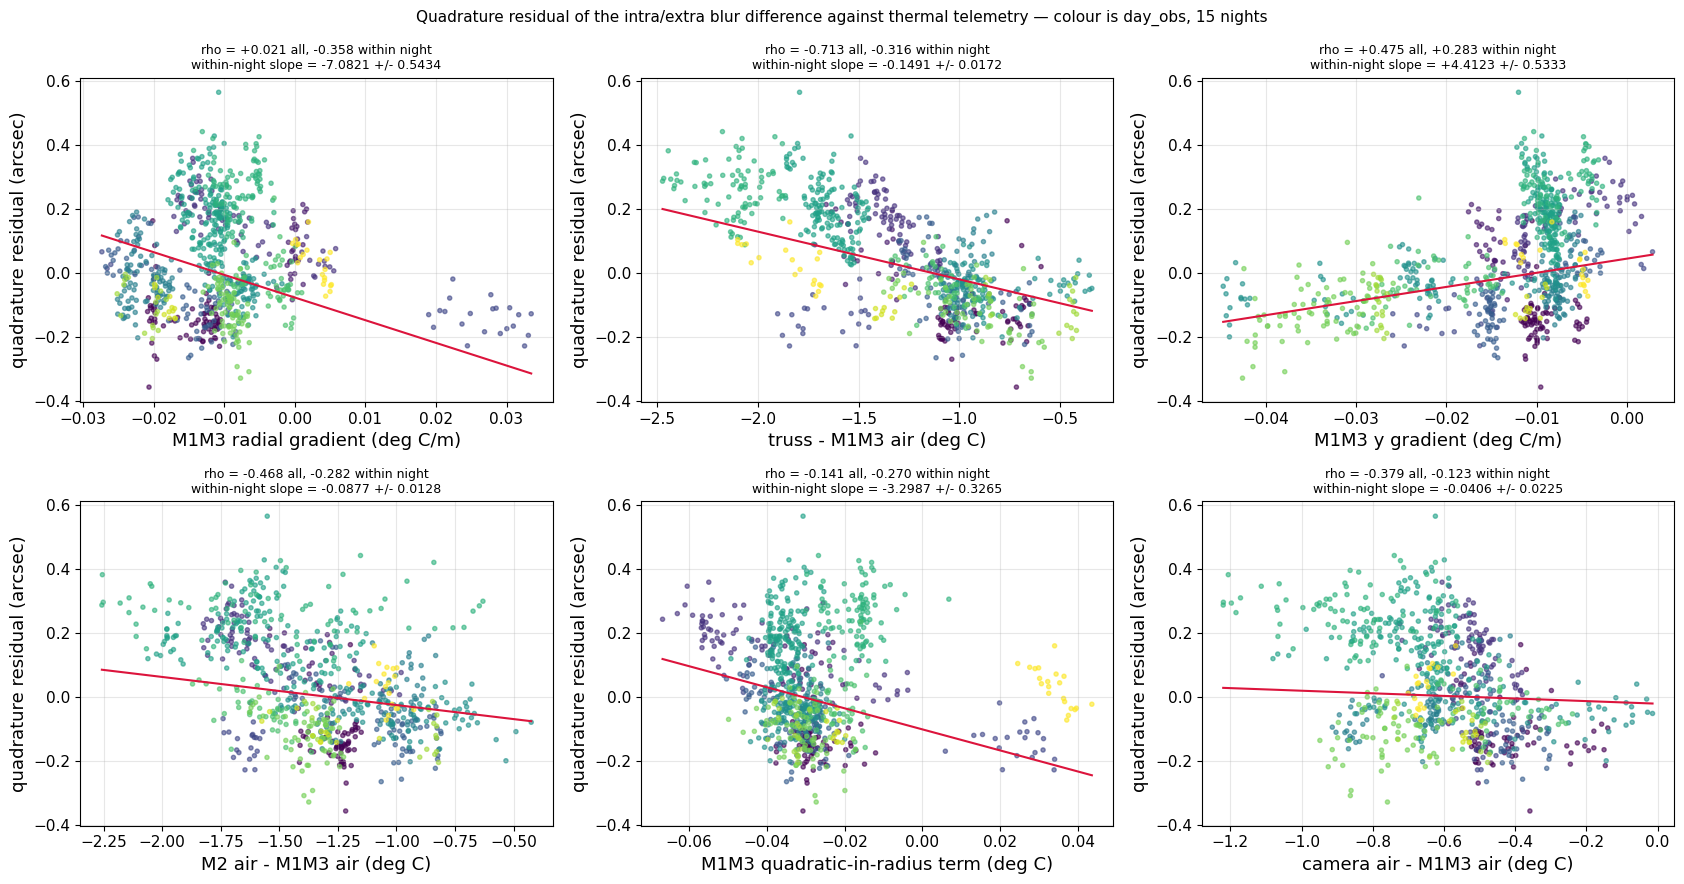

In [11]:
def within_night_huber(frame, col, target, min_per_night=MIN_NIGHT_TRIPLETS):
    """Huber robust fit of a target against one thermal quantity, within night.

    Parameters
    ----------
    frame : `pandas.DataFrame`
        One row per FAM triplet, carrying ``day_obs``, `col` and `target`.
    col : `str`
        Thermal column; its units set the slope's denominator.
    target : `str`
        Target column, in arcsec.
    min_per_night : `int`, optional
        Nights with fewer triplets are excluded, dimensionless.

    Returns
    -------
    result : `dict`
        ``slope`` and ``slope_err`` in arcsec per unit of `col`, ``n`` triplets and
        ``n_nights``, both dimensionless. The intercept is not returned: both variables
        are de-meaned per night, so it is zero by construction.
    """
    ok = np.isfinite(frame[col]) & np.isfinite(frame[target])
    sub = frame[ok]
    sub = sub[sub.groupby('day_obs')[col].transform('size') >= min_per_night]
    x = (sub[col] - sub.groupby('day_obs')[col].transform('mean')).to_numpy(float)
    y = (sub[target] - sub.groupby('day_obs')[target].transform('mean')).to_numpy(float)
    fit = sm.RLM(y, sm.add_constant(x), M=sm.robust.norms.HuberT()).fit()
    return {'slope': float(fit.params[1]), 'slope_err': float(fit.bse[1]),
            'n': int(len(sub)), 'n_nights': int(sub['day_obs'].nunique())}


TOP_N = 6
top = corr_quad.head(TOP_N)

fig, axs = plt.subplots(2, 3, figsize=(17, 9))
nights = sorted(d['day_obs'].unique())
cmap = plt.get_cmap('viridis')
night_color = {n: cmap(i / max(len(nights) - 1, 1)) for i, n in enumerate(nights)}

for ax, (_, row) in zip(axs.ravel(), top.iterrows()):
    col = row['column']
    ok = np.isfinite(d[col]) & np.isfinite(d['quad_resid_arcsec'])
    sub = d[ok]
    ax.scatter(sub[col], sub['quad_resid_arcsec'], s=9, alpha=0.6,
               c=[night_color[n] for n in sub['day_obs']])

    fit = within_night_huber(d, col, 'quad_resid_arcsec')
    # The fitted line is drawn through the sample centroid: the fit itself is on
    # night-de-meaned variables, so only its slope is meaningful here.
    xg = np.linspace(sub[col].min(), sub[col].max(), 50)
    x0 = float(np.median(sub[col]))
    y0 = float(np.median(sub['quad_resid_arcsec']))
    ax.plot(xg, y0 + fit['slope'] * (xg - x0), color='crimson', linewidth=1.5)

    ax.set_xlabel(row['feature'])
    ax.set_ylabel('quadrature residual (arcsec)')
    ax.set_title(f"rho = {row['spearman_rho']:+.3f} all, "
                 f"{row['spearman_rho_within_night']:+.3f} within night\n"
                 f"within-night slope = {fit['slope']:+.4f} +/- {fit['slope_err']:.4f}",
                 fontsize=9)

fig.suptitle(f'Quadrature residual of the intra/extra blur difference against thermal '
             f'telemetry — colour is day_obs, {len(nights)} nights', fontsize=11)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(OUT_DIR / 'blur_diff_vs_thermal.pdf')
plt.show()


### Raw versus within-night, side by side

One figure makes the point of the whole section: the full-sample correlation against the
within-night correlation, per quantity. A point far from the diagonal is a quantity whose
apparent relation to the intra/extra difference is night-level covariance and nothing
more.


/lscratch/roodman/ipykernel_3523135/1651381119.py:24: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


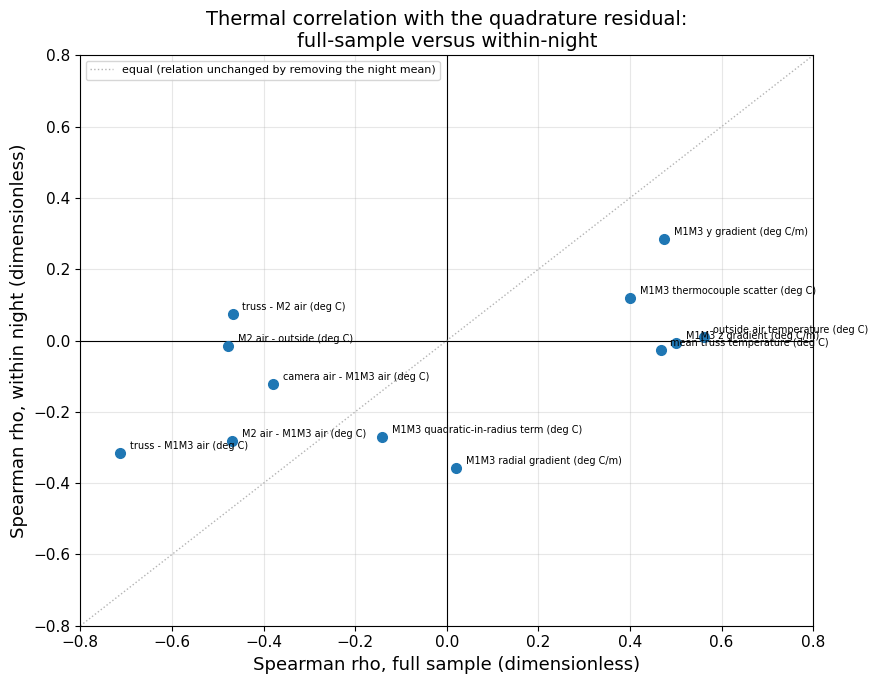

In [12]:
fig, ax = plt.subplots(figsize=(9, 7))

ax.axhline(0.0, color='k', linewidth=0.8)
ax.axvline(0.0, color='k', linewidth=0.8)
lim = 0.8
ax.plot([-lim, lim], [-lim, lim], color='0.7', linestyle=':', linewidth=1.0,
        label='equal (relation unchanged by removing the night mean)')

for _, row in corr_quad.iterrows():
    ax.plot(row['spearman_rho'], row['spearman_rho_within_night'], marker='o',
            markersize=7, color='#1f77b4')
    ax.annotate(row['feature'], (row['spearman_rho'],
                                 row['spearman_rho_within_night']),
                textcoords='offset points', xytext=(7, 3), fontsize=7)

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel('Spearman rho, full sample (dimensionless)')
ax.set_ylabel('Spearman rho, within night (dimensionless)')
ax.set_title('Thermal correlation with the quadrature residual:\n'
             'full-sample versus within-night')
ax.legend(fontsize=8, loc='upper left')

fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(OUT_DIR / 'blur_diff_thermal_raw_vs_within_night.pdf')
plt.show()


### Joint fit

The surviving quantities are not independent — the air temperature differences share the
M1M3 air sensor, and the M1M3 gradients come from the same thermocouple grid. A joint
Huber fit on night-de-meaned variables says how much of the within-night scatter they
explain together, as opposed to each one restating the same thing.


In [13]:
joint_cols = [c for c in corr_quad['column'].head(4)]

ok = np.isfinite(d['quad_resid_arcsec'])
for c in joint_cols:
    ok &= np.isfinite(d[c])
sub = d[ok]
sub = sub[sub.groupby('day_obs')['quad_resid_arcsec'].transform('size')
          >= MIN_NIGHT_TRIPLETS]

y = (sub['quad_resid_arcsec']
     - sub.groupby('day_obs')['quad_resid_arcsec'].transform('mean')).to_numpy(float)
X = np.column_stack([
    (sub[c] - sub.groupby('day_obs')[c].transform('mean')).to_numpy(float)
    for c in joint_cols])

joint = sm.RLM(y, sm.add_constant(X), M=sm.robust.norms.HuberT()).fit()
pred = joint.fittedvalues

label_of = dict(zip(corr_quad['column'], corr_quad['feature']))
print(f'Joint Huber fit of the night-de-meaned quadrature residual in arcsec, '
      f'n = {len(sub)} triplets, {sub["day_obs"].nunique()} nights\n')
for i, c in enumerate(joint_cols):
    unit = label_of[c].split('(')[-1].rstrip(')')
    print(f'  {label_of[c]:42s} slope = {joint.params[i + 1]:+.5f} '
          f'+/- {joint.bse[i + 1]:.5f} arcsec per {unit}')

print(f'\nresidual nMAD before the fit = {nmad(y):.5f} arcsec')
print(f'residual nMAD after the fit  = {nmad(y - pred):.5f} arcsec')
print(f'reduction = {1.0 - nmad(y - pred) / nmad(y):.4f} '
      f'(dimensionless, fraction of robust scatter in arcsec, not of variance)')

r_j, p_j = stats.pearsonr(pred, y)
rho_j, p_rho_j = stats.spearmanr(pred, y)
print(f'\njoint prediction vs night-de-meaned quadrature residual, both arcsec, '
      f'n = {len(sub)} triplets:')
print(f'  Pearson r    = {r_j:+.4f} (p = {p_j:.3e})')
print(f'  Spearman rho = {rho_j:+.4f} (p = {p_rho_j:.3e})')

# How much of the night-to-night spread the same model would explain, for comparison:
# the per-night means of the same quantities against the per-night mean residual.
nightly = sub.groupby('day_obs').agg(
    {**{c: 'mean' for c in joint_cols}, 'quad_resid_arcsec': 'mean'})
rho_n, p_n = stats.spearmanr(
    nightly[joint_cols[0]], nightly['quad_resid_arcsec'])
print(f'\nper-night means, {label_of[joint_cols[0]]} vs mean quadrature residual '
      f'in arcsec, n = {len(nightly)} nights:')
print(f'  Spearman rho = {rho_n:+.4f} (p = {p_n:.3e})')


Joint Huber fit of the night-de-meaned quadrature residual in arcsec, n = 793 triplets, 14 nights

  M1M3 radial gradient (deg C/m)             slope = -4.64592 +/- 0.56052 arcsec per deg C/m
  truss - M1M3 air (deg C)                   slope = -0.12287 +/- 0.01949 arcsec per deg C
  M1M3 y gradient (deg C/m)                  slope = +2.78300 +/- 0.57705 arcsec per deg C/m
  M2 air - M1M3 air (deg C)                  slope = +0.00352 +/- 0.01486 arcsec per deg C

residual nMAD before the fit = 0.07194 arcsec
residual nMAD after the fit  = 0.06239 arcsec
reduction = 0.1327 (dimensionless, fraction of robust scatter in arcsec, not of variance)

joint prediction vs night-de-meaned quadrature residual, both arcsec, n = 793 triplets:
  Pearson r    = +0.4592 (p = 1.271e-42)
  Spearman rho = +0.4604 (p = 7.495e-43)

per-night means, M1M3 radial gradient (deg C/m) vs mean quadrature residual in arcsec, n = 14 nights:
  Spearman rho = +0.1824 (p = 5.325e-01)


<a id='summary'></a>
## Summary


In [14]:
print(f'{PARAM_SET}: {n_fit} FAM triplets with a finite blur median on both sides\n')
print(f'median intra-focal blur     = {np.median(bi):.4f} arcsec')
print(f'median extra-focal blur     = {np.median(be):.4f} arcsec')
print(f'median (intra - extra)      = {np.median(bi - be):+.4f} arcsec')
print(f'median (intra / extra)      = {np.median(bi / be):.4f} (dimensionless)')
print(f'fraction with intra > extra = {float(np.mean(bi > be)):.4f} '
      f'(dimensionless, of {n_fit} triplets)\n')
for name in ('constant', 'fractional', 'quadrature'):
    m = models[name]
    print(f'{name:11s}: param = {m["param"]:+.5f} {m["param_units"]:28s} '
          f'resid nMAD = {m["nmad_arcsec"]:.5f} arcsec')
print(f'\nlowest robust residual scatter: {best}')
print(f'slope of (intra - extra) on extra blur = {slope:+.5f} +/- {slope_err:.5f} '
      f'(dimensionless)')

print()
print('Thermal dependence of the quadrature residual, within night '
      f'({len(sub)} triplets, {sub["day_obs"].nunique()} nights of >= '
      f'{MIN_NIGHT_TRIPLETS} triplets):')
for _, row in corr_quad.head(4).iterrows():
    print(f'  {row["feature"]:42s} rho = {row["spearman_rho"]:+.4f} full sample, '
          f'{row["spearman_rho_within_night"]:+.4f} within night (dimensionless)')
print(f'  joint Huber fit cuts the within-night robust scatter from {nmad(y):.5f} to '
      f'{nmad(y - pred):.5f} arcsec')
print()
print('Quantities whose full-sample correlation is night-level covariance only '
      '(within-night |rho| < 0.1):')
for _, row in corr_quad.iterrows():
    if abs(row['spearman_rho_within_night']) < 0.1:
        print(f'  {row["feature"]:42s} rho = {row["spearman_rho"]:+.4f} full sample, '
              f'{row["spearman_rho_within_night"]:+.4f} within night (dimensionless)')


danish_1_3_test: 873 FAM triplets with a finite blur median on both sides

median intra-focal blur     = 1.0526 arcsec
median extra-focal blur     = 0.6636 arcsec
median (intra - extra)      = +0.3440 arcsec
median (intra / extra)      = 1.4999 (dimensionless)
fraction with intra > extra = 0.9954 (dimensionless, of 873 triplets)

constant   : param = +0.34395 arcsec                       resid nMAD = 0.20379 arcsec
fractional : param = +1.49989 dimensionless (intra/extra)  resid nMAD = 0.23984 arcsec
quadrature : param = +0.56140 arcsec**2                    resid nMAD = 0.17863 arcsec

lowest robust residual scatter: quadrature
slope of (intra - extra) on extra blur = -0.57640 +/- 0.03444 (dimensionless)

Thermal dependence of the quadrature residual, within night (793 triplets, 14 nights of >= 5 triplets):
  M1M3 radial gradient (deg C/m)             rho = +0.0209 full sample, -0.3583 within night (dimensionless)
  truss - M1M3 air (deg C)                   rho = -0.7126 full sample,